## Install Dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

In [2]:
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)            # every time you run your code, you get the exact same sequence of "random" numbers

## Data Generation

In [3]:
n_samples = 150

# Simple Linear: 1 feature, straight-line relationship
X_lin = np.linspace(0, 10, n_samples).reshape(-1, 1)
y_lin = 2.5 * X_lin.squeeze() + 3 + np.random.randn(n_samples) * 2

# Multiple Regression: 3 features, linear combination
X_mul = np.random.randn(n_samples, 3)
y_mul = (1.2 * X_mul[:, 0] + 
         0.8 * X_mul[:, 1] - 
         1.5 * X_mul[:, 2] + 5 + np.random.randn(n_samples) * 1.5)

# Polynomial Regression: 1 feature, quadratic relationship
X_poly = np.linspace(-3, 3, n_samples).reshape(-1, 1)
y_poly = (0.8 * X_poly.squeeze()**2 - 
          1.5 * X_poly.squeeze() + 2 + np.random.randn(n_samples) * 0.8)

## Train-test Split

In [4]:
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_mul, y_mul, test_size=0.2, random_state=42)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y_poly, test_size=0.2, random_state=42)

## Define the Model

In [5]:
model_lin = LinearRegression()
model_lin.fit(X_train_l, y_train_l)
y_pred_l = model_lin.predict(X_test_l)
mse_l = mean_squared_error(y_test_l, y_pred_l)
r2_l = r2_score(y_test_l, y_pred_l)

In [6]:
model_mul = LinearRegression()
model_mul.fit(X_train_m, y_train_m)
y_pred_m = model_mul.predict(X_test_m)
mse_m = mean_squared_error(y_test_m, y_pred_m)
r2_m = r2_score(y_test_m, y_pred_m)


In [8]:
degree = 3
model_poly = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model_poly.fit(X_train_p, y_train_p)
y_pred_p = model_poly.predict(X_test_p)
mse_p = mean_squared_error(y_test_p, y_pred_p)
r2_p = r2_score(y_test_p, y_pred_p)

## Evaluation Metrics

In [9]:
print("\n" + "="*50)
print(" 📈 EVALUATION METRICS (Test Set) ")
print("="*50)
print(f"{'Model':<25} | {'MSE':<10} | {'R² Score':<10}")
print("-"*50)
print(f"{'Linear Regression':<25} | {mse_l:<10.3f} | {r2_l:<10.3f}")
print(f"{'Multiple Regression':<25} | {mse_m:<10.3f} | {r2_m:<10.3f}")
print(f"{'Polynomial Regression (d=3)':<25} | {mse_p:<10.3f} | {r2_p:<10.3f}")


 📈 EVALUATION METRICS (Test Set) 
Model                     | MSE        | R² Score  
--------------------------------------------------
Linear Regression         | 3.462      | 0.943     
Multiple Regression       | 2.549      | 0.494     
Polynomial Regression (d=3) | 0.542      | 0.948     


## Vizualization

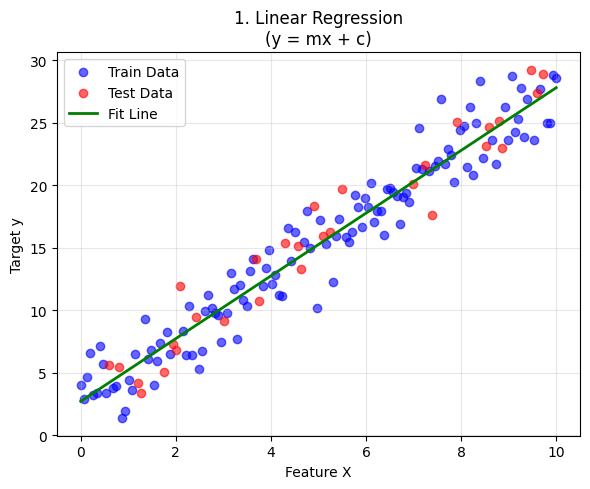

In [10]:
plt.figure(figsize=(6, 5))
plt.scatter(X_train_l, y_train_l, color='blue', alpha=0.6, label='Train Data')
plt.scatter(X_test_l, y_test_l, color='red', alpha=0.6, label='Test Data')
plt.plot(X_lin, model_lin.predict(X_lin), color='green', linewidth=2, label='Fit Line')

plt.title('1. Linear Regression\n(y = mx + c)')
plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

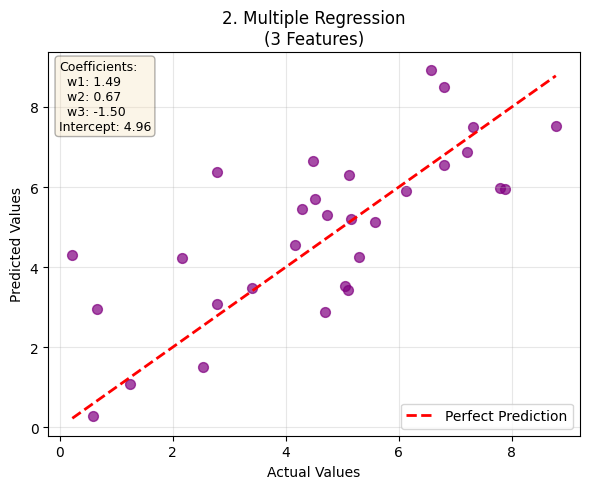

In [11]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test_m, y_pred_m, color='purple', alpha=0.7, s=50)
plt.plot([y_test_m.min(), y_test_m.max()], 
         [y_test_m.min(), y_test_m.max()], 
         'r--', linewidth=2, label='Perfect Prediction')

plt.title('2. Multiple Regression\n(3 Features)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True, alpha=0.3)

# Add coefficient annotations
coeffs = model_mul.coef_
intercept = model_mul.intercept_
info_text = f'Coefficients:\n'
for i, c in enumerate(coeffs):
    info_text += f'  w{i+1}: {c:.2f}\n'
info_text += f'Intercept: {intercept:.2f}'

# Use plt.gca().transAxes to handle the text positioning in a standalone plot
plt.text(0.02, 0.98, info_text, transform=plt.gca().transAxes, 
         fontsize=9, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

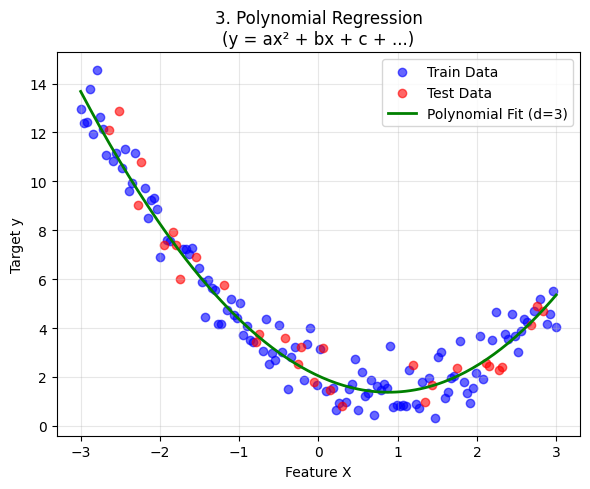

In [12]:
X_poly_sorted = np.linspace(X_poly.min(), X_poly.max(), 200).reshape(-1, 1)
y_poly_pred = model_poly.predict(X_poly_sorted)

plt.figure(figsize=(6, 5))
plt.scatter(X_train_p, y_train_p, color='blue', alpha=0.6, label='Train Data')
plt.scatter(X_test_p, y_test_p, color='red', alpha=0.6, label='Test Data')
plt.plot(X_poly_sorted, y_poly_pred, color='green', linewidth=2, label=f'Polynomial Fit (d={degree})')

plt.title('3. Polynomial Regression\n(y = ax² + bx + c + ...)')
plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()